In [65]:
from ast import literal_eval
import numpy as np
import matplotlib.pyplot as plt

In [42]:
#################################
# define ENAS hyper-parameters
#################################
NB_GENERATIONS = 10
POPULATION_SIZE = 100
NB_BEST_MODELS_CROSSOVER = 20  # specifies the number of models that will be used for crossover
MUTATION_RATE = 10  # in percent

MAX_NB_FEATURE_LAYERS = 20  # max number layers before GAP, GMP or Flatten layer in the first generation
MAX_NB_CLASSIFICATION_LAYERS = 8  # max number layers after GAP, GMP or Flatten layer in the first generation

PATH_GENE_POOL = "gene_pool.txt"
PATH_RULE_SET = "rule_set.txt"

#################################
# define DNN training hyper-parameters
#################################
INPUT_SHAPE = (16000, 1)
NB_CLASSES = 2
NB_EPOCHS = 10
BATCH_SIZE = 64
NB_MODELS_TRAINED_PARALLEL = 10

#################################
# define constraints
#################################
MAX_MEMORY_FOOTPRINT = 900000  # in Bytes (900000 bytes --> 0.9 MB)
MIN_INFERENCE_SPEED = 200  # in ms
MAX_POWER_CONSUMPTION = 1.4  # in mJ --> TODO: find out a reasonable number

params = {'generations': NB_GENERATIONS,
          'population_size': POPULATION_SIZE,
          'nb_best_models_crossover': NB_BEST_MODELS_CROSSOVER,
          'mutation_rate': MUTATION_RATE,
          'max_nb_feature_layers': MAX_NB_FEATURE_LAYERS,
          'max_nb_classification_layers': MAX_NB_CLASSIFICATION_LAYERS,
          'path_gene_pool': PATH_GENE_POOL,
          'path_rule_set': PATH_RULE_SET,
          'input_shape': INPUT_SHAPE,
          'nb_classes': NB_CLASSES,
          'nb_epochs': NB_EPOCHS,
          'batch_size': BATCH_SIZE,
          'nb_models_trained_parallel': NB_MODELS_TRAINED_PARALLEL,
          'max_memory_footprint': MAX_MEMORY_FOOTPRINT,
          'max_inference_speed': MIN_INFERENCE_SPEED,
          'max_power_consumption': MAX_POWER_CONSUMPTION}

In [73]:
with open(params['path_gene_pool'], "r") as f:
    gene_pool = literal_eval(f.read())
with open(params['path_rule_set'], "r") as f:
    rule_set = literal_eval(f.read())
                                  

def get_random_chromosome():
    # create a gene sequence containing all layers of this random gene
    # add preprocessing layers (STFT, normalization and Resizing)
    # chromosome = [self._get_gene_with_random_parameters('STFT'), self._get_gene_with_random_parameters('NORM'),
                  # self._get_gene_with_random_parameters('RES')]
    # first layer after preprocessing layers is always 'C' or 'DC'
    gene = np.random.choice(['C', 'DC'])
    chromosome = []
    chromosome.append(_get_gene_with_random_parameters(gene))
    for _ in range(1, np.random.choice(np.arange(1, params['max_nb_feature_layers'] + 1))):
        possible_genes = _get_possible_genes(gene)  # check rule set
        gene = np.random.choice(possible_genes)
        # add current layer
        chromosome.append(_get_gene_with_random_parameters(gene))
    gene = np.random.choice(['GAP', 'GMP', 'F'])
    chromosome.append(_get_gene_with_random_parameters(gene))
    for _ in range(1, np.random.choice(np.arange(1, params['max_nb_classification_layers'] + 1))):
        possible_genes = _get_possible_genes(gene)  # check rule set
        gene = np.random.choice(possible_genes)
        # add current layer
        chromosome.append(_get_gene_with_random_parameters(gene))
    return chromosome

def _get_gene_with_random_parameters(target_gene: str) -> dict:
    """ Method to get random parameters for a given gene. """
    gene_with_random_params = {}
    for gene in gene_pool:
        # find target_gene in gene pool
        if gene['layer'] == target_gene:
            # iterate over each property of the gene and get random value for it
            for _property in gene:
                if _property == 'layer' or _property == 'f_name':
                    gene_with_random_params[_property] = gene[_property]
                elif type(gene[_property][0]) is int:
                    gene_with_random_params[_property] = int(np.random.choice(np.arange(gene[_property][0],
                                                                                        gene[_property][1] + 1,
                                                                                        gene[_property][2])))
                elif type(gene[_property][0]) is float:
                    gene_with_random_params[_property] = float(np.random.choice(np.arange(gene[_property][0],
                                                                                          gene[_property][1],
                                                                                          gene[_property][2])))
                elif type(gene[_property][0]) is str:
                    gene_with_random_params[_property] = str(np.random.choice(gene[_property]))
            break
    return gene_with_random_params

def _get_possible_genes(previous_layer):
    """
    Method to apply the previously defined rule set (rule_set.txt) given the previous layer.
    """
    if type(previous_layer) == dict:
        raise ValueError(f"Parameter 'previous_layer' has to be a layer abbreviation like 'C' or 'GMP'. "
                         f"Received {previous_layer} instead.")
    for r in rule_set:
        if r['layer'] == previous_layer:
            if 'only_allowed' in r.keys():
                return r['only_allowed']
            elif 'not_allowed' in r.keys():
                not_allowed = [d['not_allowed'] for d in rule_set if d['layer'] == previous_layer][0]
                return [d['layer'] for d in gene_pool if d['layer'] not in not_allowed]
    # return all layers if there is no entry in the rule set
    return [d['layer'] for d in gene_pool]

def _check_rule_set_violation(first_gene, second_gene):
    """
    Method that checks if the second given gene can follow after the first one.
    @return: True, if the rule set is violated. False, if the rule set is not violated. 
    """
    possible_genes = _get_possible_genes(first_gene['layer'])
    if second_gene['layer'] in possible_genes:
        return False
    else:
        return True

def _get_first_conv_layer_index(chromosome):
    """ Iterate over all genes and return the index where layer C or DC is. """
    for idx, gene in enumerate(chromosome):
        if gene['layer'] == 'C' or gene['layer'] == 'DC':
            return idx
def _get_flatten_gap_gmp_index(chromosome):
    """ Iterate over all genes and return the index where layer F, GAP or GMP is. """
    for idx, gene in enumerate(chromosome):
        if gene['layer'] == 'F' or gene['layer'] == 'GAP' or gene['layer'] == 'GMP':
            return idx

In [74]:
chromosomes = []
for _ in range(5000):
    chromosomes.append(get_random_chromosome())

C:\Users\du92wufe\AppData\Local\Temp\ipykernel_24496\2567027952.py:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  chromosome_1 = np.random.choice(chromosomes)
C:\Users\du92wufe\AppData\Local\Temp\ipykernel_24496\2567027952.py:7: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  chromosome_2 = np.random.choice(chromosomes)


(array([485.,   7.,   3.,   1.,   0.,   0.,   1.,   0.,   0.,   3.]),
 array([  1. ,  10.9,  20.8,  30.7,  40.6,  50.5,  60.4,  70.3,  80.2,
         90.1, 100. ]),
 <BarContainer object of 10 artists>)

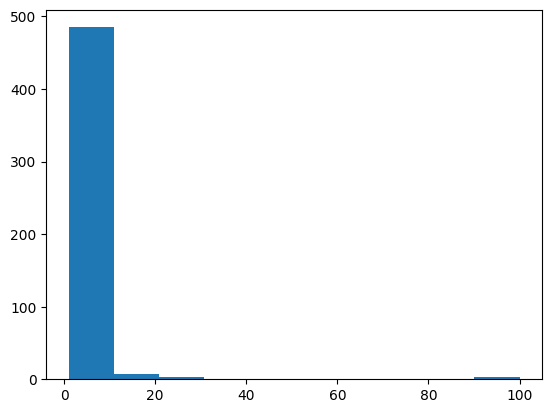

In [78]:
all_i = []
for _ in range(500):
    chromosome_1 = np.random.choice(chromosomes)
    
    chromosome_2 = chromosome_1
    while chromosome_1 == chromosome_2:
        chromosome_2 = np.random.choice(chromosomes)
        
    idx_start_1 = _get_first_conv_layer_index(chromosome_1)
    idx_start_2 = _get_first_conv_layer_index(chromosome_2)
    idx_end_1 = _get_flatten_gap_gmp_index(chromosome_1)
    idx_end_2 = _get_flatten_gap_gmp_index(chromosome_2)
    
    chr_1_split = np.random.randint(idx_start_1, idx_end_1)
    chr_2_split = np.random.randint(idx_start_2, idx_end_2)
    
    i = 0
    while True:
        i += 1
        rule_set_is_violated = _check_rule_set_violation(chromosome_1[chr_1_split], chromosome_2[chr_2_split+1])
        if not rule_set_is_violated or i == 100:
            all_i.append(i)
            break 
        else:
            chr_1_split = np.random.randint(idx_start_1, idx_end_1)
            chr_2_split = np.random.randint(idx_start_2, idx_end_2)
    
plt.hist(all_i)